In [34]:
import pandas as pd

df = pd.read_csv('combined_file.csv')

In [35]:
df

,passageid,passageclaim,claim_id,passagetext,passageheader,url,docs
0,1,Industrial furnaces are used in various indust...,0,------------------- \nAn industrial furnace i...,1: Introduction,https://www.sciencedirect.com/topics/engineeri...,['Both industrial furnaces such as rotary kiln...
1,1,"Despite their potential environmental impact, ...",2,------------------- \nAn industrial furnace i...,1: Introduction,https://www.sciencedirect.com/topics/engineeri...,['Both industrial furnaces such as rotary kiln...
2,2,Industrial furnaces can have a significant imp...,3,------------------- \nThe following factors/K...,2: Environmental Impact Factors,https://www.sciencedirect.com/topics/engineeri...,['Both industrial furnaces such as rotary kiln...
3,1,Industrial furnaces are used in various indust...,0,------------------- \nAn industrial furnace i...,1: Introduction,https://en.wikipedia.org/wiki/Industrial_furnace,"['Photograph your local culture, help Wikipedi..."
4,1,Industrial furnaces are used in various indust...,0,------------------- \nAn industrial furnace i...,1: Introduction,https://abbottfurnace.com/a-guide-to-industria...,['Industrial furnaces are used widely in indus...
...,...,...,...,...,...,...,...
356,3,By analyzing the data collected by these senso...,8,"------------------- \nIf relevant, the follow...",3 (optional): Sensor Deployment,https://www.forbes.com/sites/theyec/2023/04/14...,['This is a BETA experience. You may opt-out b...
357,3,By analyzing the data collected by these senso...,8,"------------------- \nIf relevant, the follow...",3 (optional): Sensor Deployment,https://www.mckinsey.com/capabilities/operatio...,['Please use UP and DOWN arrow keys to review ...
358,3,By analyzing the data collected by these senso...,8,"------------------- \nIf relevant, the follow...",3 (optional): Sensor Deployment,https://www.unilever.com/planet-and-society/sa...,"['- 1900 – 1950 – Joining forces, Unilever com..."
359,3,By analyzing the data collected by these senso...,8,"------------------- \nIf relevant, the follow...",3 (optional): Sensor Deployment,https://hbr.org/2023/05/how-food-companies-can...,['Environmental sustainability | How Food Co...


In [36]:
# Open the input file in read mode
docs = []
claims = []
import ast

with open('ml_training_1.txt', 'r') as file:
    # Read each line in the file
    for line in file:
        # Check if the line starts with "1 premise: B"
        if line.startswith("1 premise:"):
            # Print the line
            a = line.strip()  # strip() is used to remove any leading or trailing whitespaces
            a1, b1 = a.split('hypothesis:')
            docs.append((a1.split('1 premise: ')[1]).strip())
            claims.append(b1)


In [39]:
import ast
supports = []
for j_index, j in enumerate(df['docs']): 
    aa = ast.literal_eval(j)
    try:
        cdoc = ' '.join(aa)
    except:
        continue
    for i_index, i in enumerate(docs):
        try:
            if i in cdoc:
                supports.append((claims[i_index],df['url'][j_index],df['passageid'][j_index]))
        except:
            pass    
#print (supports)

In [40]:
for item in supports:
    print (item)

(' Industrial furnaces are used in various industries to provide thermal energy for different purposes, such as melting metals, producing cement, or creating ceramics.', 'https://www.sciencedirect.com/topics/engineering/industrial-furnace', 1)
(' Industrial furnaces are used in various industries to provide thermal energy for different purposes, such as melting metals, producing cement, or creating ceramics.', 'https://www.sciencedirect.com/topics/engineering/industrial-furnace', 1)
(' Industrial furnaces are used in various industries to provide thermal energy for different purposes, such as melting metals, producing cement, or creating ceramics.', 'https://www.sciencedirect.com/topics/engineering/industrial-furnace', 1)
(' Industrial furnaces are used in various industries to provide thermal energy for different purposes, such as melting metals, producing cement, or creating ceramics.', 'https://www.sciencedirect.com/topics/engineering/industrial-furnace', 1)
(' Industrial furnaces a

In [54]:
Db = pd.DataFrame(supports, columns=['claims','url','passageid'])
Db.drop_duplicates(inplace=True)

In [42]:
Db.to_csv('industrial_furnace_sustanability_score.csv',index=False)

In [44]:
Db.groupby('passageid').count()

,claims,url
passageid,,
1,24,24
2,14,14
3,10,10


In [53]:
Db['url'].head(100)

0      https://www.sciencedirect.com/topics/engineeri...
7      https://www.sciencedirect.com/topics/engineeri...
16     https://www.sciencedirect.com/topics/engineeri...
23     https://www.sciencedirect.com/topics/engineeri...
24     https://abbottfurnace.com/a-guide-to-industria...
25     https://www.sciencedirect.com/science/article/...
28     https://www.ulmaforge.com/en/new/industrial-ga...
35     https://www.researchgate.net/publication/33118...
39     https://www.sciencedirect.com/science/article/...
43     https://www.sciencedirect.com/science/article/...
45     https://www.sciencedirect.com/science/article/...
50     https://www.sciencedirect.com/science/article/...
87     https://www.sciencedirect.com/science/article/...
91     https://www.sciencedirect.com/science/article/...
93     https://www.sciencedirect.com/science/article/...
98     https://www.sciencedirect.com/science/article/...
103      https://www.machinemfg.com/industrial-furnaces/
104    https://www.energy.gov/e

In [46]:
grouped_df = Db.groupby('passageid').agg({'claims': pd.Series.nunique, 'url': pd.Series.nunique}).reset_index()


In [50]:
grouped_urls = Db.groupby('passageid')['url'].unique().reset_index()

# Display the grouped DataFrame
print(grouped_urls)

# Prepare LaTeX table
latex_table = grouped_urls.to_latex(index=False)
print(latex_table)

   passageid                                                url
0          1  [https://www.sciencedirect.com/topics/engineer...
1          2  [https://www.sciencedirect.com/topics/engineer...
2          3  [https://www.researchgate.net/publication/3715...
\begin{tabular}{rl}
\toprule
 passageid &                                                url \\
\midrule
         1 & [https://www.sciencedirect.com/topics/engineeri... \\
         2 & [https://www.sciencedirect.com/topics/engineeri... \\
         3 & [https://www.researchgate.net/publication/37155... \\
\bottomrule
\end{tabular}



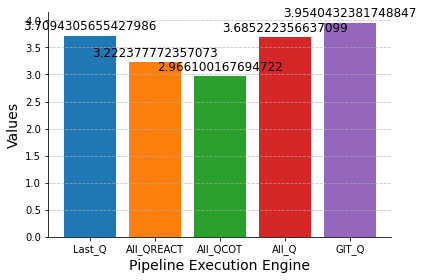

In [61]:
import matplotlib.pyplot as plt

# Data
options = ['Last_Q', 'All_QREACT', 'All_QCOT', 'All_Q', 'GIT_Q']
values = [3.7094305655427986, 3.222377772357073, 2.966100167694722, 3.685222356637099, 3.9540432381748847]

# Create a figure and axis object
fig, ax = plt.subplots()

# Plot the bar chart
bars = ax.bar(options, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

# Add labels and title
ax.set_xlabel('Pipeline Execution Engine', fontsize=14)
ax.set_ylabel('Values', fontsize=14)
#ax.set_title('Bar Chart with 5 Options', fontsize=16)

# Add gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add some extra style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}', 
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=12)

# Show the plot
plt.tight_layout()
plt.savefig('barchartplot.png')
plt.show()
